In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets
from sklearn.metrics import accuracy_score, confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns
import torch.nn.functional as F
import tqdm as tqdm

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Classificador MipGAN2/Real

In [13]:
class VGG16Classifier(nn.Module):
    def __init__(self, num_classes=2, freeze_features=True):
        super().__init__()
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        if freeze_features:
            for param in self.vgg16.features.parameters():
                param.requires_grad = False

        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.vgg16(x)

checkpoint_path = '/home/vandrade/src/notebooks/odin_cross-domain_morphs/checkpoints/mipgan2-classifier/best_vgg16_weights_mipgan2.pt'
model = VGG16Classifier(num_classes=2, freeze_features=True).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

<All keys matched successfully>

In [14]:
transformer_vgg16 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# ODIN

### 1) Temperature Scaling

$$S_i(x; T) = \frac{\exp(f_i(x) / T)}{\sum_{j=1}^{N} \exp(f_j(x) / T)}$$

$$\hat{y} = \arg\max_i S_i(x; T)$$

### 2) Perturbação da Entrada

$$L = -\log S_{\hat{y}}(x; T)$$

$$\tilde{x} = x - \epsilon \cdot \text{sign}(\nabla_x L)$$

### 3) Inferência com ODIN
Forward pass da imagem perturbada $\tilde{x}$

$$C(\tilde{x}) = \max_i S_i(\tilde{x}; T)$$

### 4) Decisão
A partir de um threshold $\delta$, a decisão é definida como:

$$
\text{Decisão} =  \begin{cases}
  \text{In-Distribution}, & \text{se } C(\tilde{x}) \ge \delta \\
  \text{Out-of-Distribution}, & \text{se } C(\tilde{x}) < \delta
\end{cases}
$$

In [15]:
def apply_odin(image, model, temperature=1000.0, epsilon=0.0014):
    image = image.to(device)
    image.requires_grad = True #habilitar calculo do grad na imagem

    # forward pass
    outputs = model(image)

    # f_i(x)/temperatura
    outputs = outputs / temperature
    predicted_class = outputs.argmax(dim=1)

    # cross-entropy loss = -log(Softmax).
    loss = F.cross_entropy(outputs, predicted_class)

    # backward pass (gradiente)
    model.zero_grad() #remove acumulo dos gradientes
    loss.backward() #calcula dLoss/dPixels

    # sign(grad_x)
    gradient_sign = torch.sign(image.grad)

    # perturbação x~
    perturbed_image = image - epsilon * gradient_sign

    return perturbed_image.detach() #retorno da imagem (com requires_grad = False)

In [16]:
def get_confidence_odin(image, model, T=1000, eps=0.0014):
    image = apply_odin(image, model, temperature=T, epsilon=eps)

    with torch.no_grad():
      outputs = model(image) / T
      probs = F.softmax(outputs, dim=1)
      max_prob, _ = torch.max(probs, dim=1)

    return max_prob.detach().cpu().tolist()

def get_confidence(image, model):
    with torch.no_grad():
      outputs = model(image)
      probs = F.softmax(outputs, dim=1)
      max_prob, _ = torch.max(probs, dim=1)

    return max_prob.detach().cpu().tolist()

In [17]:
def evaluate_ood_behavior(model, id_loader, ood_loader, T=1000.0, eps=0.0014, id_class="", ood_class=""):
    model.eval()
    
    id_conf_baseline = []
    id_conf_odin = []
    
    ood_conf_baseline = []
    ood_conf_odin = []
    
    print("Avaliando In-Distribution (ID)...")
    for images, _ in id_loader:
        images = images.to(device)
        id_conf_baseline.extend(get_confidence(images, model))
        id_conf_odin.extend(get_confidence_odin(images, model, T, eps))
        
    print("Avaliando Out-of-Distribution (OOD)...")
    for images, _ in ood_loader:
        images = images.to(device)
        ood_conf_baseline.extend(get_confidence(images, model))
        ood_conf_odin.extend(get_confidence_odin(images, model, T, eps))
        
    # Plot histograma
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Baseline
    sns.histplot(id_conf_baseline, color='blue', alpha=0.5, label=f'ID ({id_class})', ax=axes[0], stat='density', bins=30, kde=True, line_kws={'linewidth': 2})
    sns.histplot(ood_conf_baseline, color='red', alpha=0.5, label=f'OOD ({ood_class})', ax=axes[0], stat='density', bins=30, kde=True, line_kws={'linewidth': 2})
    axes[0].set_title('Baseline (Sem ODIN)')
    axes[0].set_xlabel('Confiança (Max Softmax)')
    axes[0].set_ylabel('Densidade')
    axes[0].legend()
    
    # ODIN
    sns.histplot(id_conf_odin, color='blue', alpha=0.5, label=f'ID ({id_class})', ax=axes[1], stat='density', bins=30, kde=True, line_kws={'linewidth': 2})
    sns.histplot(ood_conf_odin, color='red', alpha=0.5, label=f'OOD ({ood_class})', ax=axes[1], stat='density', bins=30, kde=True, line_kws={'linewidth': 2})
    axes[1].set_title(f'ODIN (T={T}, eps={eps})')
    axes[1].set_xlabel('Confiança ODIN')
    axes[1].set_ylabel('Densidade')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

### Conjunto de Teste: 167 fakes vs 167 reais

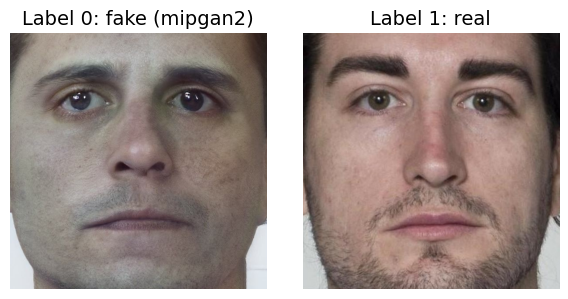

In [18]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/mipgan2_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_mipgan2 = None

for img, label in dataset_vis:
    if label == 0 and img_mipgan2 is None:
        img_mipgan2 = img
        label_mipgan2 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_mipgan2 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_mipgan2}: {classes[label_mipgan2]} (mipgan2)", fontsize=14)
axes[0].imshow(img_mipgan2)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [19]:
mip2_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/mipgan2_real/test', transform=transformer_vgg16)
mip2_test_loader = DataLoader(dataset=mip2_test_set, batch_size=32, shuffle=False)

print(f"classes: {mip2_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.9731


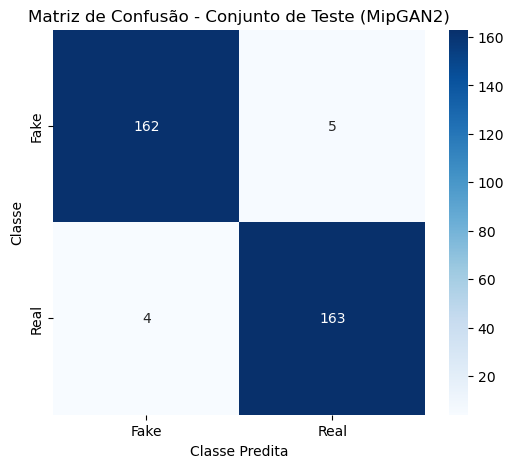

In [20]:
model.eval()

all_mip2_preds = []
all_mip2_targets = []

with torch.inference_mode():
    for X, y in mip2_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_mip2_preds.extend(preds.cpu().numpy())
        all_mip2_targets.extend(y.cpu().numpy())

acc_mip2 = accuracy_score(all_mip2_targets, all_mip2_preds)
print(f"Acurácia: {acc_mip2:.4f}")

cm = confusion_matrix(all_mip2_targets, all_mip2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Conjunto de Teste (MipGAN2)')
plt.show()

# Out-of-Distribution

In [21]:
temperatures = [5, 10, 50, 100, 500, 1000]

## Inferência StyleGan 2

### Conjunto de Teste: 167 fakes vs 167 reais

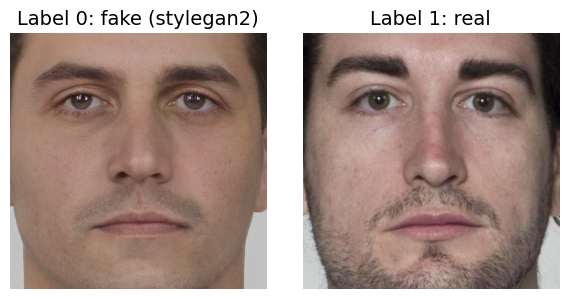

In [22]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan2_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan2 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan2 is None:
        img_stylegan2 = img
        label_stylegan2 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan2 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan2}: {classes[label_stylegan2]} (stylegan2)", fontsize=14)
axes[0].imshow(img_stylegan2)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [23]:
stg2_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan2_real/test', transform=transformer_vgg16)
stg2_test_loader = DataLoader(dataset=stg2_test_set, batch_size=32, shuffle=False)

print(f"classes: {stg2_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.9790


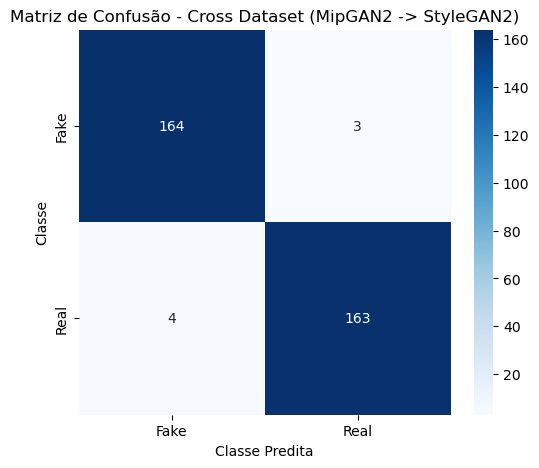

In [24]:
model.eval()

all_stg2_preds = []
all_stg2_targets = []

with torch.inference_mode():
    for X, y in stg2_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg2_preds.extend(preds.cpu().numpy())
        all_stg2_targets.extend(y.cpu().numpy())

acc_stg2 = accuracy_score(all_stg2_targets, all_stg2_preds)
print(f"Acurácia: {acc_stg2:.4f}")

cm = confusion_matrix(all_stg2_targets, all_stg2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], 
            yticklabels=['Fake', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Cross Dataset (MipGAN2 -> StyleGAN2)')
plt.show()

Avaliando In-Distribution (ID)...


Avaliando Out-of-Distribution (OOD)...


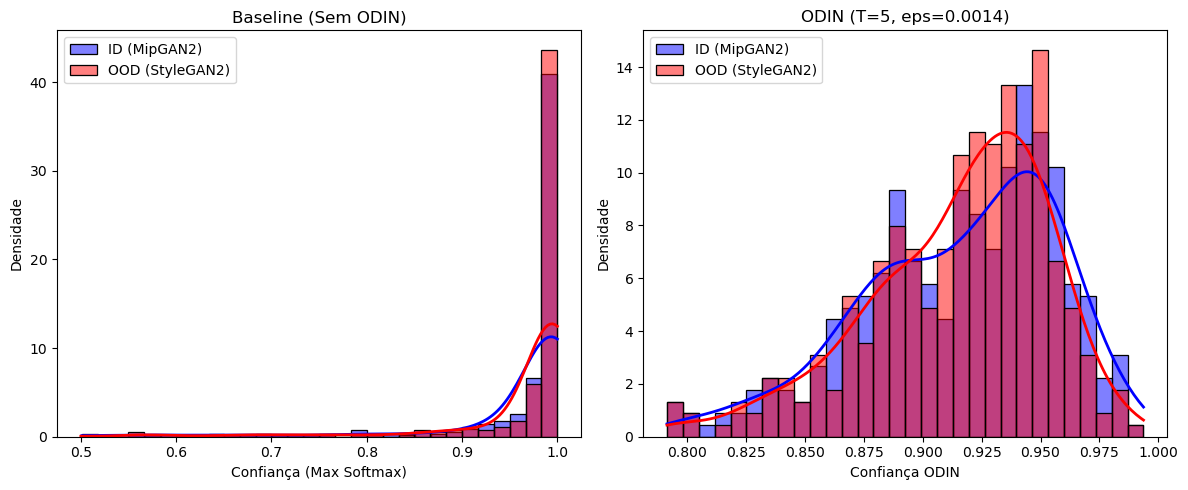

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


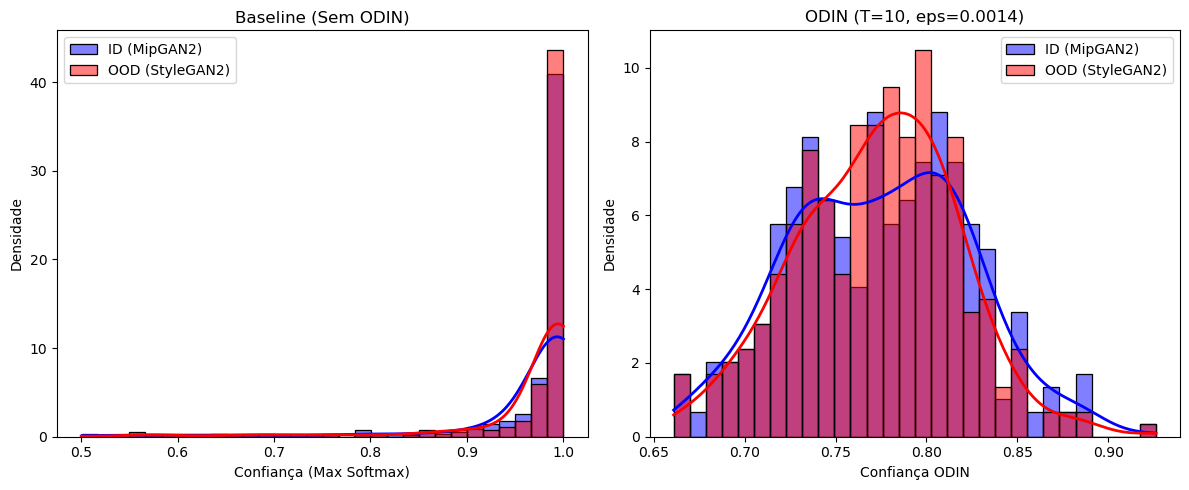

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


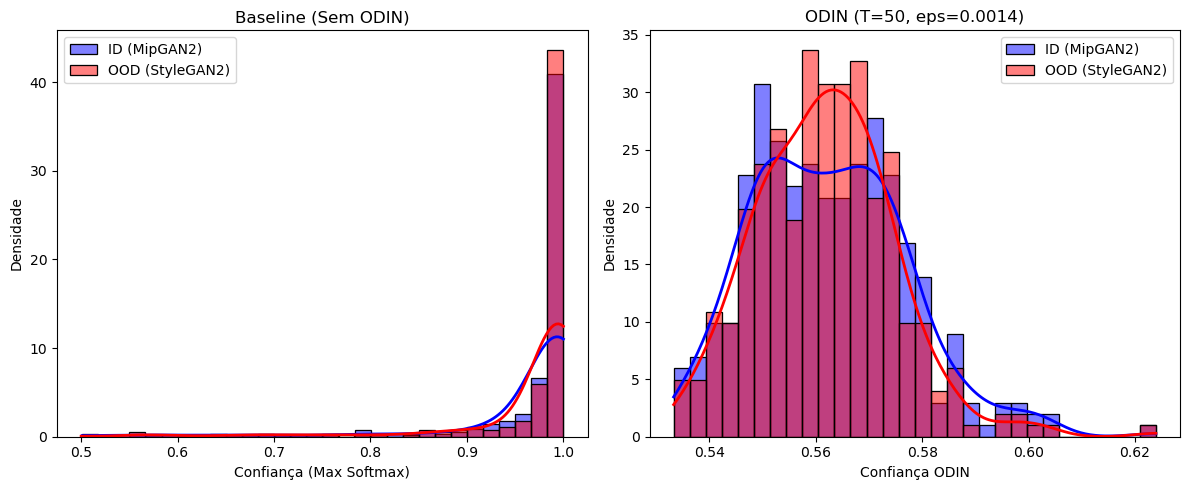

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


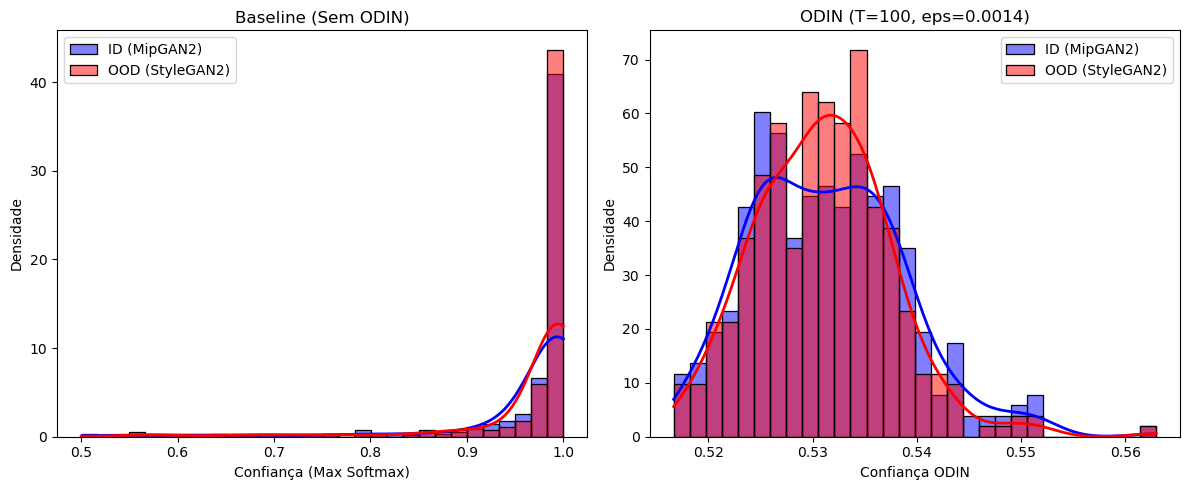

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


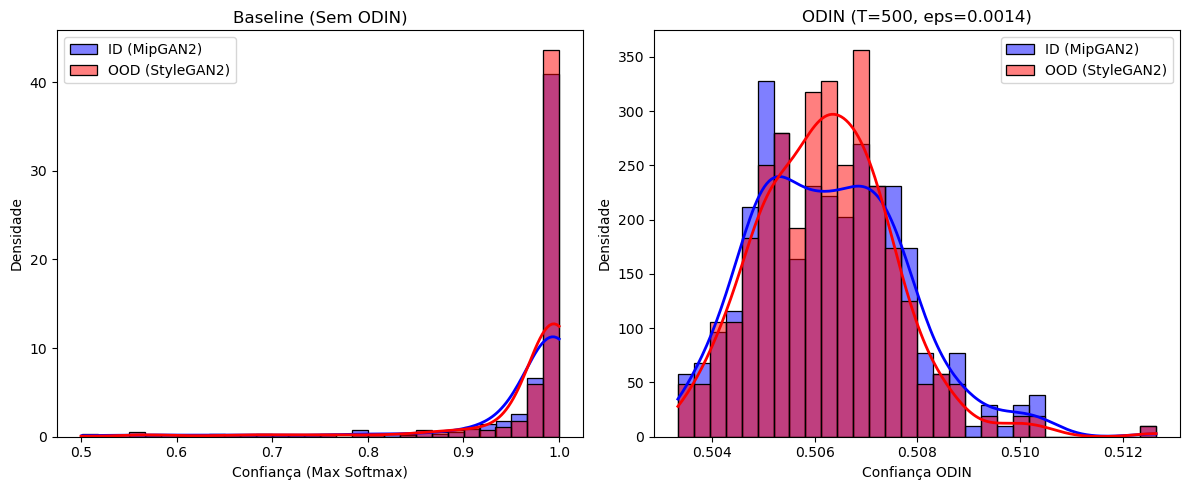

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


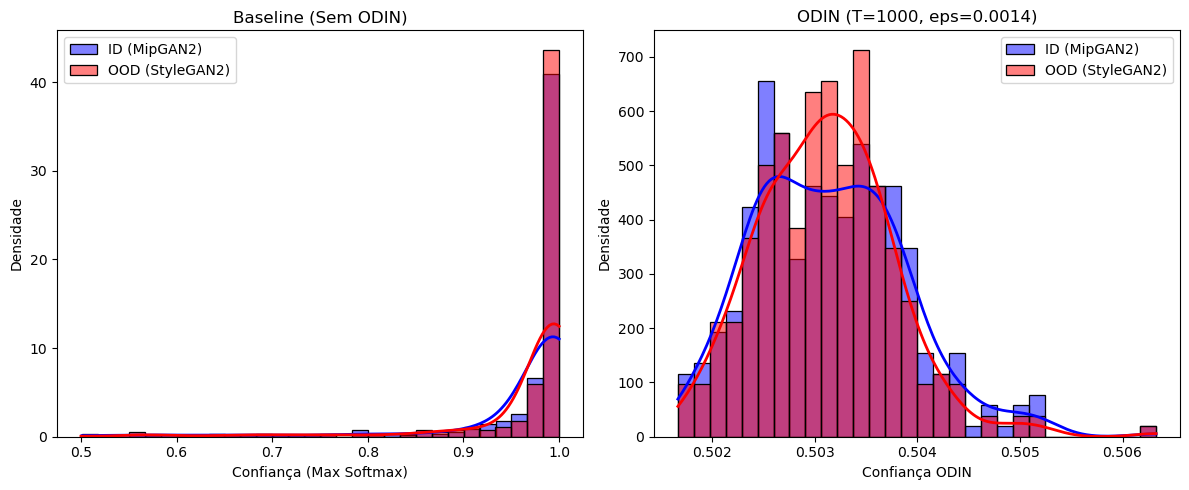

In [25]:
for temperature in temperatures:
    evaluate_ood_behavior(model, mip2_test_loader, stg2_test_loader, T=temperature, eps=0.0014, id_class="MipGAN2", ood_class="StyleGAN2")

# Inferência StyleGan3

### Conjunto de Teste: 167 fakes vs 167 reais

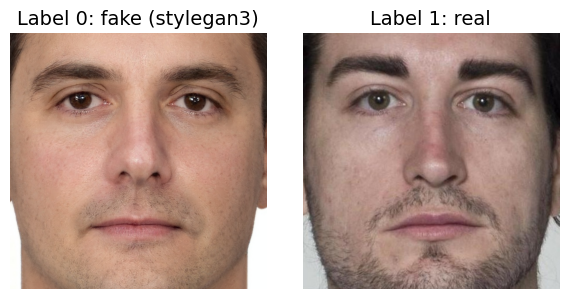

In [26]:
dataset_vis = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=None)
classes = dataset_vis.classes

img_real = None
img_stylegan3 = None

for img, label in dataset_vis:
    if label == 0 and img_stylegan3 is None:
        img_stylegan3 = img
        label_stylegan3 = label
    elif label == 1 and img_real is None:
        img_real = img
        label_real = label
    
    if img_real is not None and img_stylegan3 is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].set_title(f"Label {label_stylegan3}: {classes[label_stylegan3]} (stylegan3)", fontsize=14)
axes[0].imshow(img_stylegan3)
axes[0].axis("off")

axes[1].set_title(f"Label {label_real}: {classes[label_real]}", fontsize=14)
axes[1].imshow(img_real)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [27]:
stg3_test_set = datasets.ImageFolder(root='/home/vandrade/data/cross-domain_morphs/stylegan3_real/test', transform=transformer_vgg16)
stg3_test_loader = DataLoader(dataset=stg3_test_set, batch_size=32, shuffle=False)

print(f"classes: {stg3_test_set.classes}")

classes: ['fake', 'real']


Acurácia: 0.8772


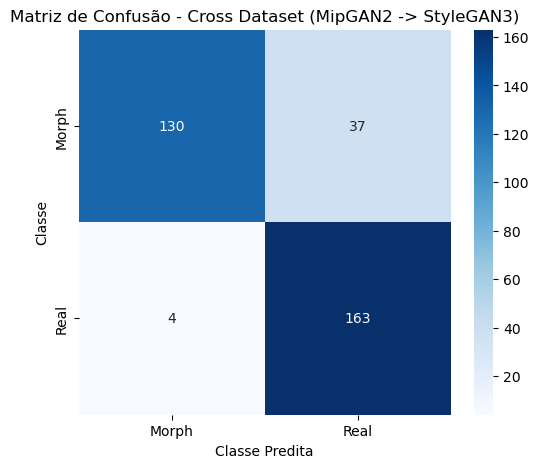

In [28]:
model.eval()

all_stg3_preds = []
all_stg3_targets = []

with torch.inference_mode():
    for X, y in stg3_test_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg3_preds.extend(preds.cpu().numpy())
        all_stg3_targets.extend(y.cpu().numpy())

acc_stg3 = accuracy_score(all_stg3_targets, all_stg3_preds)
print(f"Acurácia: {acc_stg3:.4f}")

cm = confusion_matrix(all_stg3_targets, all_stg3_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Morph', 'Real'], 
            yticklabels=['Morph', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe')
plt.title('Matriz de Confusão - Cross Dataset (MipGAN2 -> StyleGAN3)')
plt.show()

Avaliando In-Distribution (ID)...


Avaliando Out-of-Distribution (OOD)...


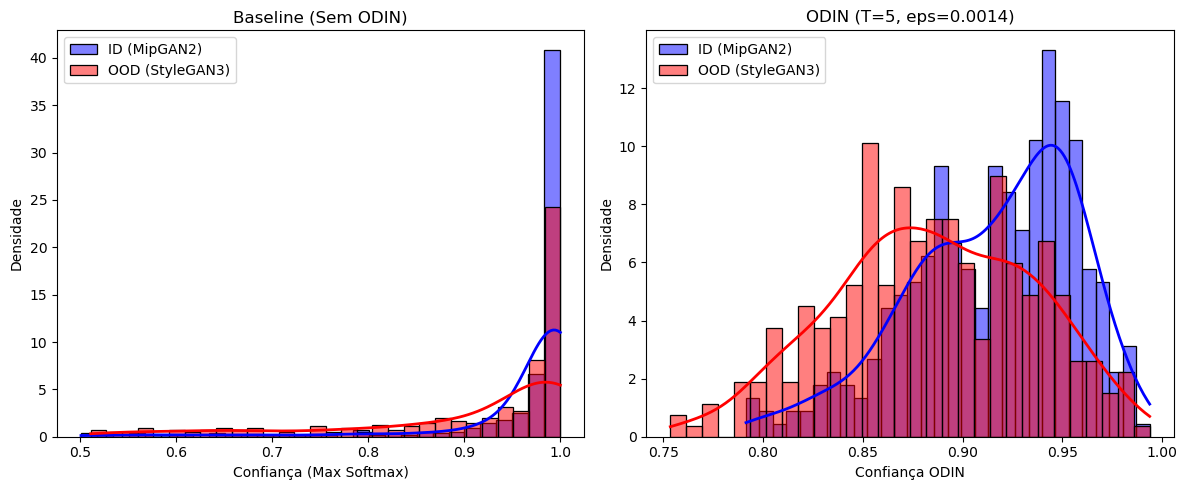

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


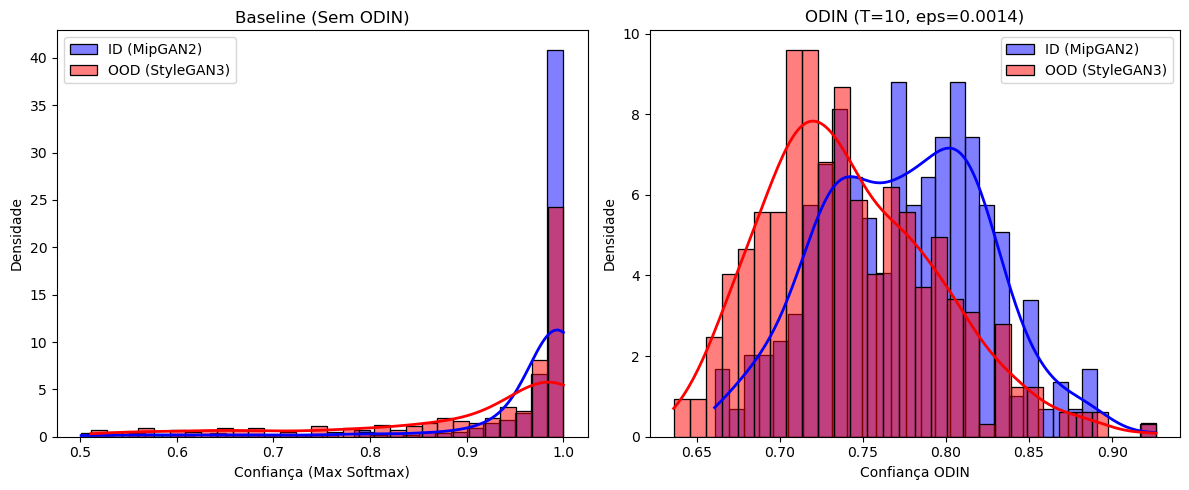

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


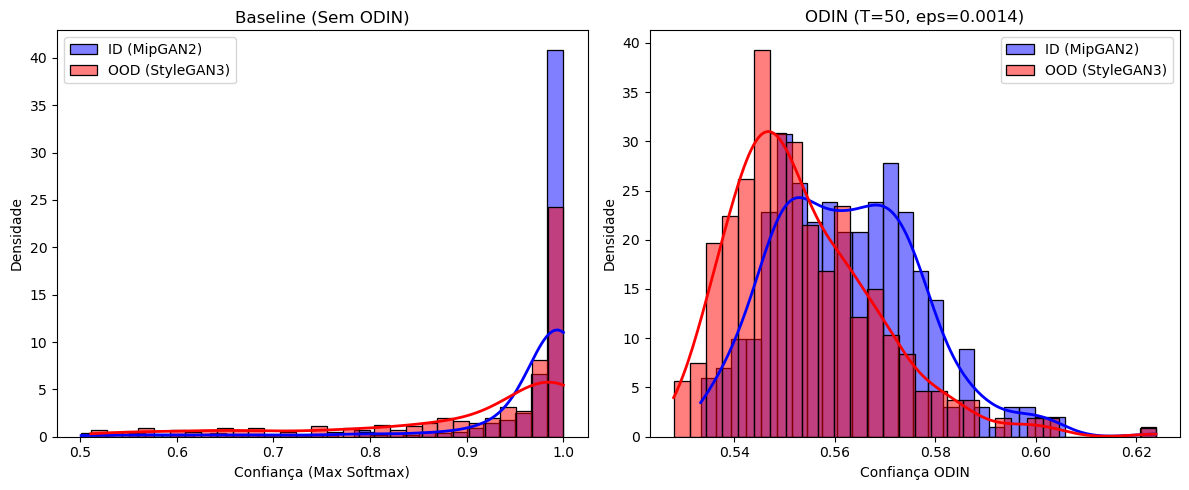

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


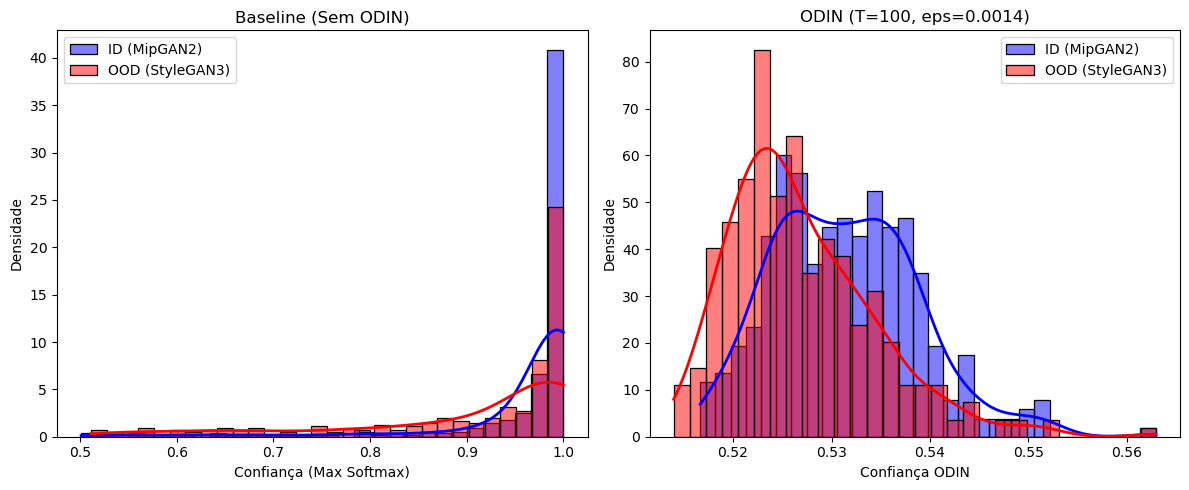

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


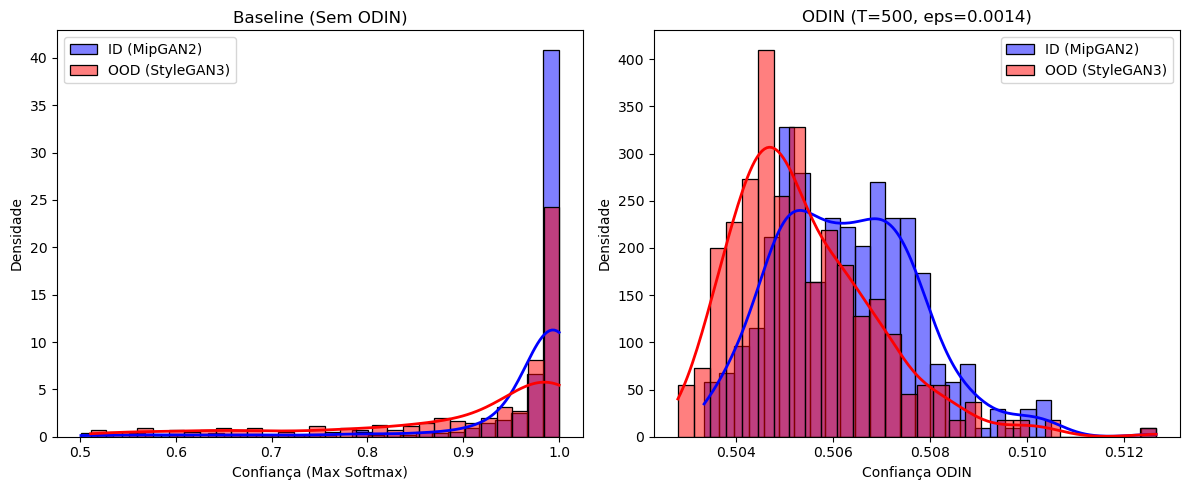

Avaliando In-Distribution (ID)...
Avaliando Out-of-Distribution (OOD)...


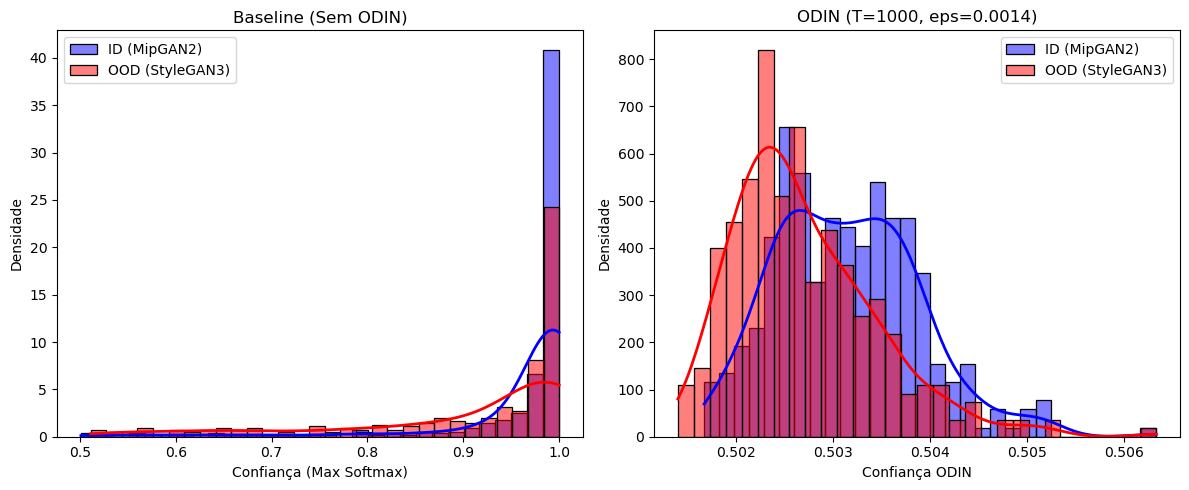

In [29]:
for temperature in temperatures:
    evaluate_ood_behavior(model, mip2_test_loader, stg3_test_loader, T=temperature, eps=0.0014, id_class="MipGAN2", ood_class="StyleGAN3")